In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv('UsArrests.csv')
df.head()

,City,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [4]:
# Load dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   City      50 non-null     str    
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), str(1)
memory usage: 2.1 KB


In [6]:
# Get a quick look at the dataset numbers
df.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


In [7]:
# Change the City column to be the index of the dataframe
df = df.rename(columns={'City': 'State'})
df = df.set_index('State')
df.head()

,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [8]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

With the current state of the data, "Assault" has the largest variance and will dominate the unscaled PCA as currently constructed. I will standardize the data next. 

In [9]:
# Standardize the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

scaled_df = pd.DataFrame(df_scaled, columns=df.columns, index=df.index)
scaled_df.head()

,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,1.255179,0.790787,-0.526195,-0.003451
Alaska,0.513019,1.118060,-1.224067,2.509424
Arizona,0.072361,1.493817,1.009122,1.053466
Arkansas,0.234708,0.233212,-1.084492,-0.186794
California,0.281093,1.275635,1.776781,2.088814


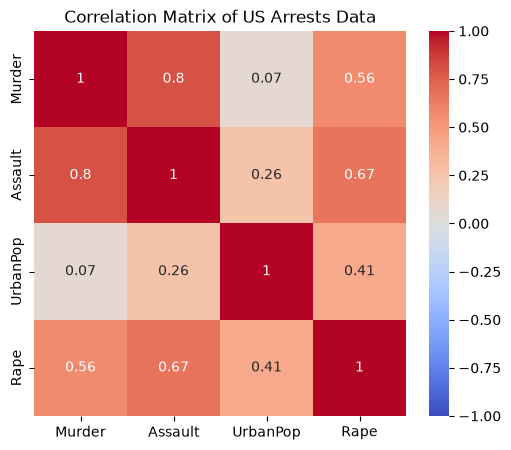

In [10]:
# Compute the correlation matrix
corr_matrix = df.corr()
corr_matrix

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of US Arrests Data')
plt.show()

The heatmap above shows that the three crime variables are all moderately to strongly correlated. Murder and Assault show the strongest relationship at 0.80. Assault and Rape have a correlation of 0.67 and Murder and Rape have a relationship of 0.56 which is classified as moderately correlated. This implies that states with high crime rates in one area are likely to have increased crime rates in other areas as well. On the other hand, UrbanPop is weakly correlated or not correlated at all to the crime variables depending on which variable you look at. PCA should find one principal component that reveals "overall crime" and a separate uncorrelated component that captures "urbanization". 

In [14]:
# Fit PCA on the scaled data
from sklearn.decomposition import PCA

pca = PCA()
pca_scores = pca.fit_transform(scaled_df)

# Turn into a labeled DataFrame — one row per state, one column per PC
pc_labels = [f'PC{i+1}' for i in range(pca_scores.shape[1])]
pca_df = pd.DataFrame(pca_scores, index=scaled_df.index, columns=pc_labels)
pca_df.head()

,PC1,PC2,PC3,PC4
State,,,,
Alabama,0.985566,-1.133392,-0.444269,-0.156267
Alaska,1.950138,-1.073213,2.040003,0.438583
Arizona,1.763164,0.745957,0.054781,0.834653
Arkansas,-0.141420,-1.119797,0.114574,0.182811
California,2.523980,1.542934,0.598557,0.341996


In [15]:
# Check the total variance per component
print(pca.explained_variance_ratio_)

[0.62006039 0.24744129 0.0891408  0.04335752]


In [16]:
# Loadings convey how much each original variable contributes to each principal component
# Examine the PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=scaled_df.columns,
    columns=pc_labels
)
loadings

,PC1,PC2,PC3,PC4
Murder,0.535899,-0.418181,-0.341233,-0.649228
Assault,0.583184,-0.187986,-0.268148,0.743407
UrbanPop,0.278191,0.872806,-0.378016,-0.133878
Rape,0.543432,0.167319,0.817778,-0.089024


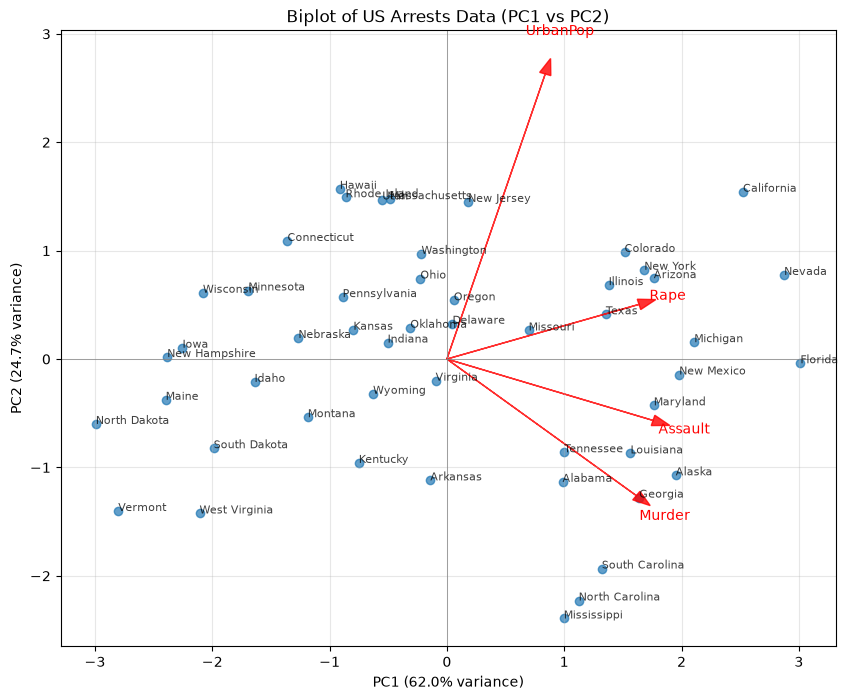

In [17]:
# Plot a biplot of the first two principal components
def biplot(scores, loadings, labels, feature_names, pc_x=0, pc_y=1):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot the state scores
    ax.scatter(scores[:, pc_x], scores[:, pc_y], alpha=0.7)
    for i, label in enumerate(labels):
        ax.annotate(label, (scores[i, pc_x], scores[i, pc_y]), fontsize=8, alpha=0.75)
    
    # Scale factor so the arrows are visible alongside the score points
    scale = np.max(np.abs(scores[:, [pc_x, pc_y]])) * 1.0
    
    # Plot the loading vectors (arrows)
    for i, feature in enumerate(feature_names):
        ax.arrow(0, 0, 
                  loadings[i, pc_x] * scale, loadings[i, pc_y] * scale,
                  color='red', alpha=0.8, head_width=0.1)
        ax.text(loadings[i, pc_x] * scale * 1.15, loadings[i, pc_y] * scale * 1.15,
                 feature, color='red', ha='center', va='center', fontsize=10)
    
    ax.set_xlabel(f'PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]*100:.1f}% variance)')
    ax.set_ylabel(f'PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]*100:.1f}% variance)')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.axvline(0, color='grey', linewidth=0.5)
    ax.set_title('Biplot of US Arrests Data (PC1 vs PC2)')
    ax.grid(alpha=0.3)
    plt.show()

biplot(pca_scores, pca.components_.T, df.index, df.columns)


The biplot shows both the state scores and the loading vectors. States on the right side of the horizontal axis are associated with higher crime rates while states on the left have lower crime rates. The vertical axis represents urbanization with the most urbanized states being near the top and they appear lower on the graph as they are less and less urbanized. The loading arrows are included to confirm the pattern that was shown on the correlation matrix. 
A comparison that stood out to me almost instantaneously is that Georgia and Mississippi are towards the lower end of the right side while California is far right but high. This means that the states have similar PC1 scores but that PC2 indicates the different urban levels. This illustrates why I felt a need to keep both PC1 and PC2. They are both valuable in understanding the data. 

Cumulative explained variance: [0.62006039 0.86750168 0.95664248 1.        ]


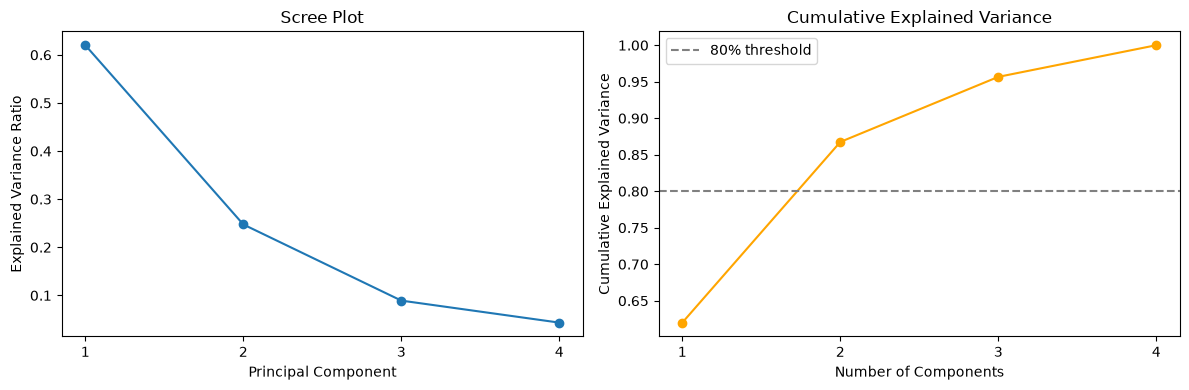

In [18]:
# Decide how many components to keep
# Create a scree plot to visualize the explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative explained variance:", cumulative_variance)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
axes[0].plot(range(1, 5), pca.explained_variance_ratio_, marker='o')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, 5))

# Cumulative variance plot
axes[1].plot(range(1, 5), cumulative_variance, marker='o', color='orange')
axes[1].axhline(0.8, color='grey', linestyle='--', label='80% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, 5))
axes[1].legend()

plt.tight_layout()
plt.show()

I have selected two principal components to use in further analysis. PC1 and PC2 explain a combined 86.75% of the total variance in the data. The target threshold is 80% so I am comfortable in using these two principal components for further analysis. Also, PC1 and PC2 both have separate distinguishing factors. PC1 represents overall violent crime rate and PC2 represents urbanization. This distinction is meaningful for clustering and interpretation. 

In [19]:
# The first two principal components kept for downstream analysis
pca_2d = pca_df[['PC1', 'PC2']]
pca_2d.head()

,PC1,PC2
State,,
Alabama,0.985566,-1.133392
Alaska,1.950138,-1.073213
Arizona,1.763164,0.745957
Arkansas,-0.141420,-1.119797
California,2.523980,1.542934


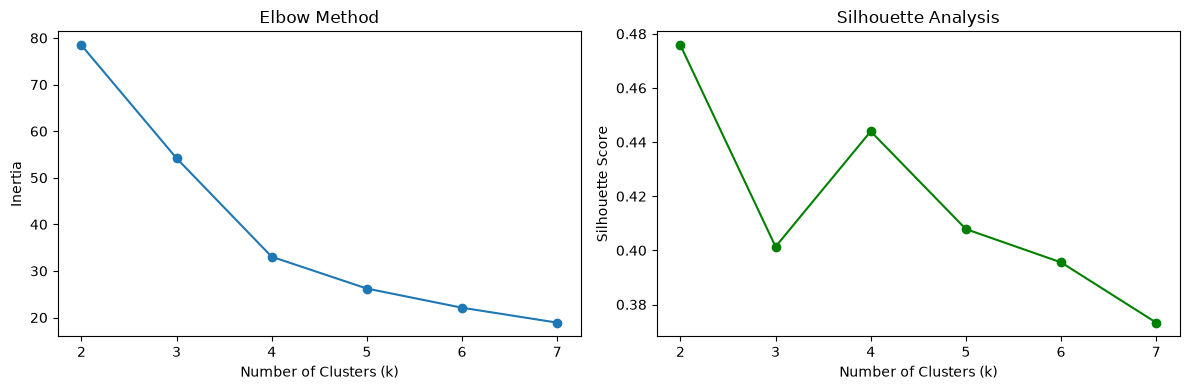

In [ ]:
# Use the elbow method to determine the optimal number of clusters for K-Means
# Combine the elbow method with silhouette scores to find the best number of clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_range = range(2, 8)  # silhouette needs at least 2 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(pca_2d)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(pca_2d, cluster_labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouette_scores, marker='o', color='green')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')

plt.tight_layout()
plt.show()


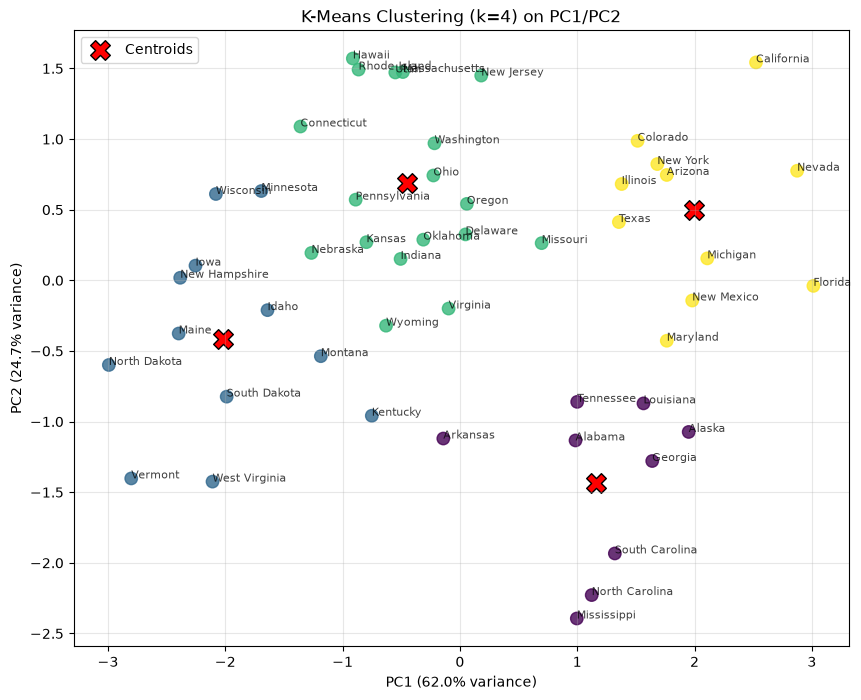

,Murder,Assault,UrbanPop,Rape
KMeans_Cluster,,,,
0,13.500000,245.777778,53.111111,23.977778
1,3.541667,76.583333,51.250000,11.816667
2,5.766667,139.000000,73.000000,19.177778
3,11.054545,264.090909,79.090909,32.618182


In [ ]:
# Fit K-Means with the chosen number of clusters
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(pca_2d)

# Attach cluster labels back to a labeled DataFrame
pca_2d_clustered = pca_2d.copy()
pca_2d_clustered['KMeans_Cluster'] = kmeans_labels

# Plot the clusters in PC1/PC2 space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_2d['PC1'], pca_2d['PC2'], c=kmeans_labels, cmap='viridis', s=80, alpha=0.8)

# Label each point with the state name
for i, state in enumerate(pca_2d.index):
    plt.annotate(state, (pca_2d['PC1'].iloc[i], pca_2d['PC2'].iloc[i]), fontsize=8, alpha=0.75)

# Plot the cluster centers
centers = kmeans_final.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centroids', edgecolor='black')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-Means Clustering (k=4) on PC1/PC2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Attach cluster labels to the unscaled data for interpretable summary stats
df_with_clusters = df.copy()
df_with_clusters['KMeans_Cluster'] = kmeans_labels

# Average crime rates and urbanization per cluster
cluster_summary = df_with_clusters.groupby('KMeans_Cluster').mean()
cluster_summary

The four clusters make up the four quadrants of the previous biplot. This is what we'd expect given that PC1 and PC2 represented those two independent dimensions. See further analysis on each individual cluster below:

Cluster 0 - High crime, low urbanization: Murder, Assault, and Rape had high rates but the lowest UrbanPop of the crime-heavy clusters at 53.1%. I'd estimate that this is where the rural yet high violenced southern states were classified.
Cluster 1 - Low crime, low urbanization: This is easily the lowest amount the three crime variables. It also has very low urbanization. This is likely rural areas but on the safe side. States could include North Dakota, Vermont, etc.
Cluster 2 - Moderate crime, high urbanization: Crime is committed at an average rate but the UrbanPop numbers are quite high when compared to clusters 0 and 1. My best assumption is that this cluster belongs to urban but moderate states.
Cluster 3 - High crime, high urbanization: This cluster contains the highest Assault and Rape rates as well as the highest UrbanPop. This must belong to big, urban, high-crime states such as California, New York, Florida, etc.

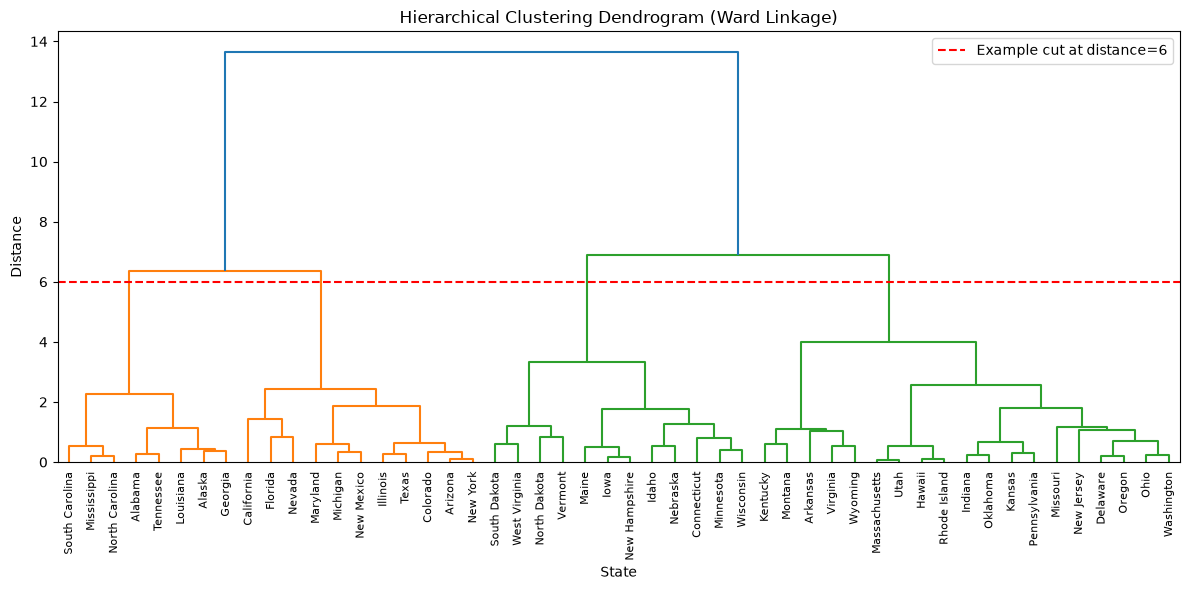

In [22]:
# Hierarchical clustering and dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# 'ward' linkage minimizes within-cluster variance, similar to K-Means
linked = linkage(pca_2d, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, labels=pca_2d.index.tolist(), leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('State')
plt.ylabel('Distance')
plt.axhline(y=6, color='red', linestyle='--', label='Example cut at distance=6')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Fit hierarchical clustering with the same number of clusters as K-Means
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(pca_2d)

# Add to the clustered dataframe for comparison
df_with_clusters['Hierarchical_Cluster'] = hierarchical_labels

# Cross-tabulate
comparison_table = pd.crosstab(
    df_with_clusters['KMeans_Cluster'],
    df_with_clusters['Hierarchical_Cluster'],
    rownames=['KMeans'],
    colnames=['Hierarchical']
)
comparison_table

Hierarchical,0,1,2,3
KMeans,,,,
0,1,0,0,8
1,2,0,10,0
2,16,0,2,0
3,0,11,0,0


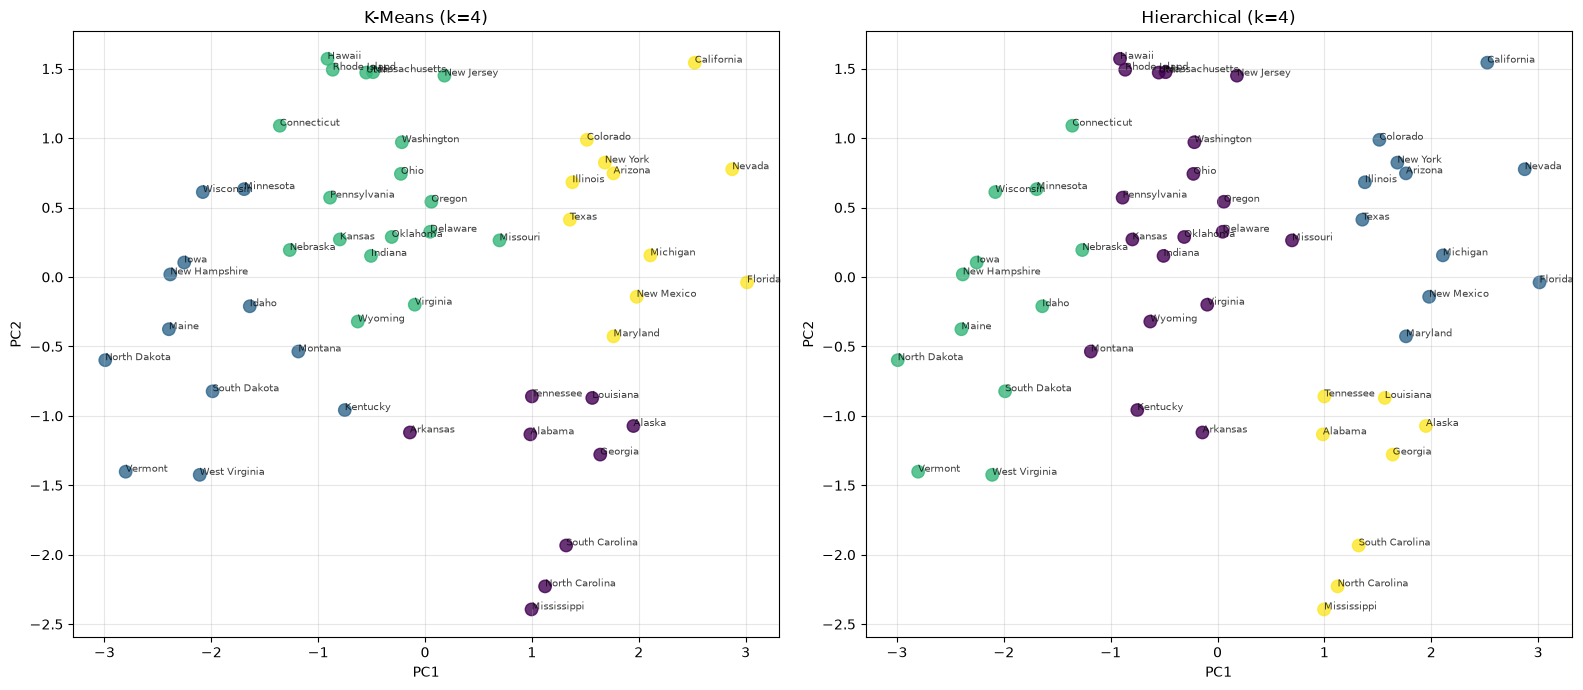

In [24]:
# Visualize hierarchical clusters side by side with K-Means.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, labels, title in zip(axes, 
                                [kmeans_labels, hierarchical_labels], 
                                ['K-Means (k=4)', 'Hierarchical (k=4)']):
    scatter = ax.scatter(pca_2d['PC1'], pca_2d['PC2'], c=labels, cmap='viridis', s=80, alpha=0.8)
    for i, state in enumerate(pca_2d.index):
        ax.annotate(state, (pca_2d['PC1'].iloc[i], pca_2d['PC2'].iloc[i]), fontsize=7, alpha=0.75)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(title)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

K-Means and Ward-linkage clustering run on the same two principal components with k=4. They both outputted similar groupings and have over 80% agreement between the two methods. The visually most obvious consistent cluster is the "high crime, high urbanization" group. The main disagreements between the two methods was in the "moderate crime, high urbanization" and "high crime, low urbanization" clusters. These states are closer to the boundary between the crime and urbanization axes and were harder to assign on a consistent basis. This makes sense since K-Means uses distance to centroids while hierarchical clustering builds up merges based on local similarity. Overall, these methods gave me confidence that the four cluster structure reflects accurate and true patterns in the data. 